In [3]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


inspection_id = "0A49KLT3B7Y" #fhr8
angle_profiles = ["0"]
num_tracks = 22
run_number = 8

In [4]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"./data-files/insp_{inspection_id}_dent_detection_ae"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-ilit0008", f"track_runs/{inspection_id}/dent_detection_ae/", results_dir)

Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000011000.0_0000012000.0_framestep_000001_margin_0.15.parquet
Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000012000.0_0000013000.0_framestep_000001_margin_0.15.parquet
Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000013000.0_0000014000.0_framestep_000001_margin_0.15.parquet
Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000014000.0_0000015000.0_framestep_000001_margin_0.15.parquet
Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000015000.0_0000016000.0_framestep_000001_margin_0.15.parquet
Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000016000.0_0000017000.0_framestep_000001_margin_0.15.parquet
Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000017000.0_0000018000.0_framestep_000001_margin_0.15.parquet
Downloading: track_runs/0A49KLT3B7Y/dent_detection_ae/distance_0000018000.0_0000019000.0_framestep_000001_margin_0.15.

In [5]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [6]:
len(data_files), data_files

(27,
 [PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae/distance_0000000000.0_0000001000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae/distance_0000001000.0_0000002000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae/distance_0000002000.0_0000003000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae/distance_0000003000.0_0000004000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae/distance_0000004000.0_0000005000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae/distance_0000005000.0_0000006000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae/distance_0000006000.0_0000007000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_a

In [7]:
pd.read_csv(data_files[7])

,start,end,prob
0,6999.85,7000.15,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,7000.00,7000.30,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,7000.15,7000.45,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,7000.30,7000.60,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,7000.45,7000.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
6664,7999.45,7999.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6665,7999.60,7999.90,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6666,7999.75,8000.05,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6667,7999.90,8000.20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [6]:
## Create a DataFrame for each profile and track and range
def create_df(frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_csv(path)
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

In [18]:
# Assuming all_dfs is your dataframe with columns: start, end, and prob
import ast

# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

# Process each threshold
thresholds = [0.05,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.97, 0.99, 0.999]
results = []
all_dfs = create_df()

for threshold in thresholds:
    # Lists to store entries that pass the threshold
    filtered_entries = []
    total_samples = len(all_dfs)
    num_positives = 0
    
    # Process each row
    for i, row in all_dfs.iterrows():
        # Parse the probability values if needed
        probs = parse_prob(row['prob'])
        
        # Check if any probability exceeds the threshold
        if any(p >= threshold for p in probs):
            # Add this entry to our filtered list
            filtered_entries.append({
                'start': row['start'],
                'end': row['end'],
                'prob': probs,
                'max_prob': max(probs)
            })
            num_positives += 1
    
    # Store results for this threshold
    results.append({
        'threshold': threshold,
        'filtered_entries': filtered_entries,
        'num_positives': num_positives,
        'total': total_samples,
        'num_positives_percent': (num_positives / total_samples) * 100 if total_samples > 0 else 0
    })
    print(f"Threshold {threshold:.3f}: {len(filtered_entries)}/{total_samples} passed "
          f"({num_positives}/{total_samples} positives, {num_positives/total_samples:.4%})")

# Plotting the results
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Extract data for plotting
thresholds = [r['threshold'] for r in results]
num_positives_counts = [r['num_positives'] for r in results]
num_positives_percent = [r['num_positives_percent'] for r in results]

# Create bar plot
bars = plt.bar(thresholds, num_positives_counts, width=0.03, alpha=0.7)

# Add percentage labels on top of bars
for bar, percent in zip(bars, num_positives_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percent:.3f}%', ha='center', va='bottom')


# Add labels and title
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Positives')
plt.title('Positive Samples vs. Confidence Threshold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add second y-axis for percentage
ax2 = plt.gca().twinx()
ax2.set_ylabel('Percent Positives (%)')
ax2.plot(thresholds, num_positives_percent, 'r-', alpha=0)  # Invisible, just for scale
ax2.set_ylim(0, max(num_positives_percent) * 1.1)

plt.show()

Threshold 0.050: 75/175430 passed (75/175430 positives, 0.0428%)
Threshold 0.400: 56/175430 passed (56/175430 positives, 0.0319%)
Threshold 0.500: 53/175430 passed (53/175430 positives, 0.0302%)


KeyboardInterrupt: 

In [14]:
# Access filtered entries for threshold 0.9
entries_09 = results[0]['filtered_entries']  # Index 5 corresponds to threshold 0.9
print(f"Found {len(entries_09)} entries")

# Optional: Create a new DataFrame with filtered entries
import pandas as pd
filtered_df = pd.DataFrame(entries_09)
display(filtered_df)

Found 72 entries


,start,end,prob,max_prob
0,0.90,1.20,"[0.0012, 0.0, 0.0007, 0.0, 0.0, 0.0098, 0.0, 0...",0.8142
1,1.50,1.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.1034
2,1.80,2.10,"[0.0029, 0.0087, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.5115
3,1.95,2.25,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.2249
4,2.10,2.40,"[0.4052, 0.2091, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.4052
...,...,...,...,...
67,26304.20,26304.50,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0003, 0.8718, 0.0,...",0.8718
68,26304.35,26304.65,"[0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....",0.3528
69,26304.50,26304.80,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.000...",0.9942
70,26304.65,26304.95,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0649, 0.0001,...",0.1276


In [15]:
def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with larger start value.
    
    Args:
        df: DataFrame with 'start' column
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start column in descending order (larger values first)
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Initialize with first row (largest start value)
    kept_indices = [0]
    last_kept_start = df_sorted.loc[0, 'start']
    
    # Process remaining rows
    for i in range(1, len(df_sorted)):
        current_start = df_sorted.loc[i, 'start']
        
        # If far enough from last kept row, keep this one too
        # Note: Since we're going from larger to smaller, the comparison is flipped
        if last_kept_start - current_start >= distance_threshold:
            kept_indices.append(i)
            last_kept_start = current_start
    
    # Return dataframe with only kept rows
    return df_sorted.loc[kept_indices].reset_index(drop=True)

# Example usage
filtered_df_deduped = filter_close_detections(filtered_df)
print(f"Original detections: {len(filtered_df)}")
print(f"After deduplication: {len(filtered_df_deduped)}")

Original detections: 72
After deduplication: 57


In [16]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation

root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)

session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=num_tracks,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.colorbar()
        plt.show()
    return img


PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8083, Concurrent Connections: 1
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8083, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8083) : 200, 28ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8083) : 200, 191ms
PySession.cpp(84): Initialized with inspection: 0A49KLT3B7Y
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8083, Concurrent Connections: 3
PigSpatialModel.cpp(302): vehicle 4 -> disk 5 -> FrontSlot has a track assignm

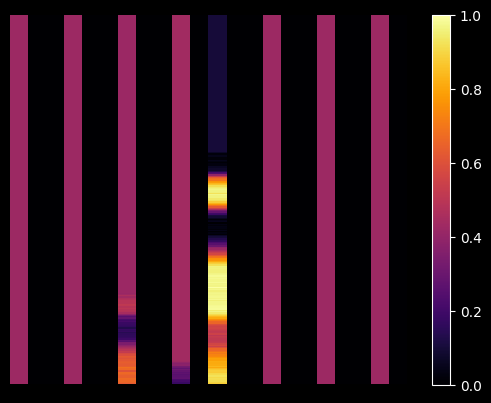

26304.95000000296 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9519, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


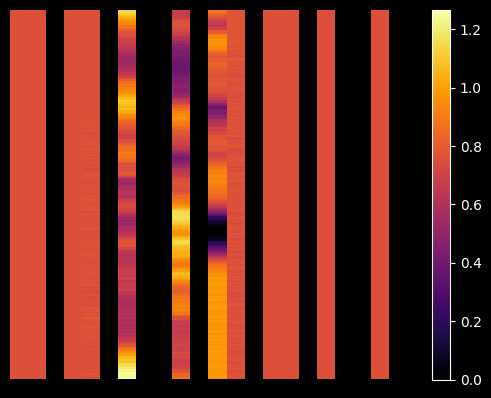

26304.650000002955 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0002, 0.9942, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


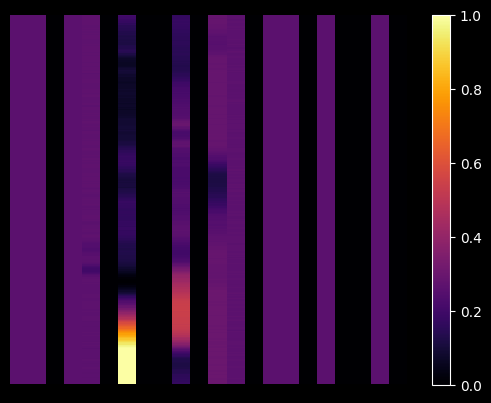

26304.350000002953 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0003, 0.8718, 0.0, 0.0013, 0.0283, 0.0, 0.0025, 0.0005, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


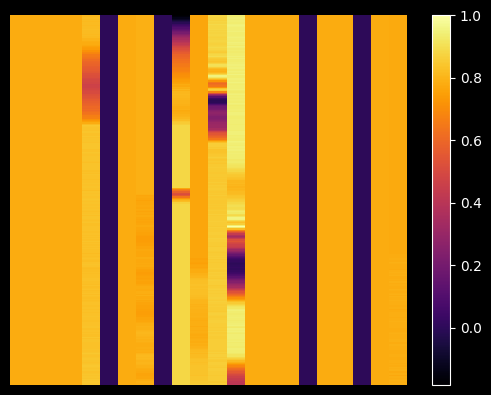

26304.05000000295 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0726, 0.9915, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


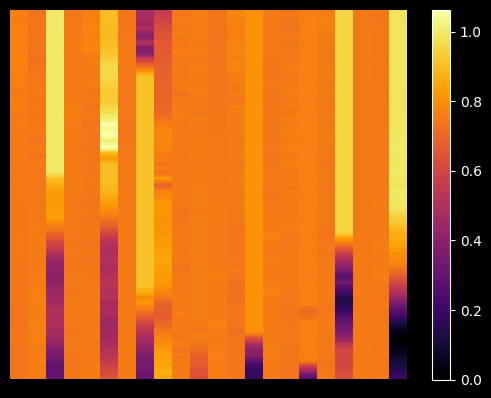

26303.000000002936 [0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.9843, 0.0042, 0.6193, 0.6193]


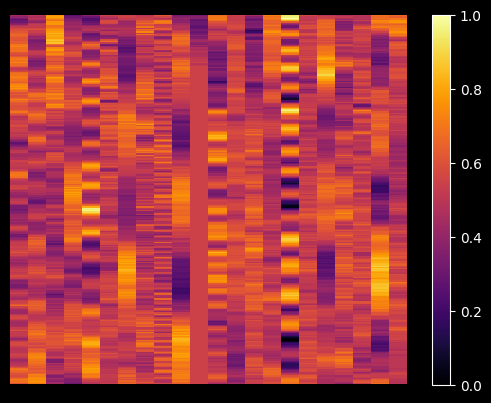

26301.95000000293 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5112, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


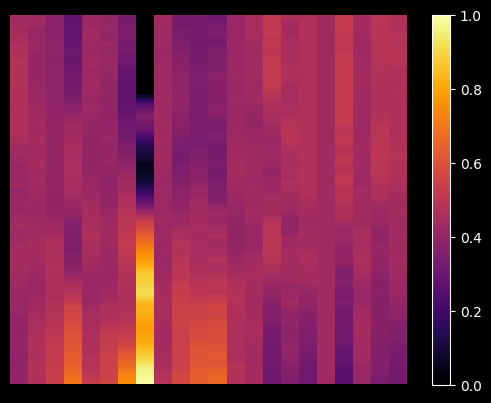

26269.10000000261 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.4038, 0.9969, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


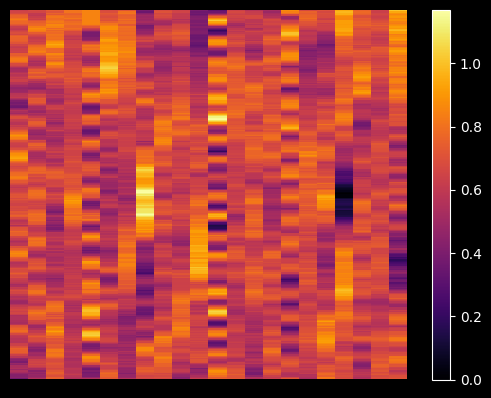

26267.450000002595 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.8988, 0.0, 0.0, 0.0]


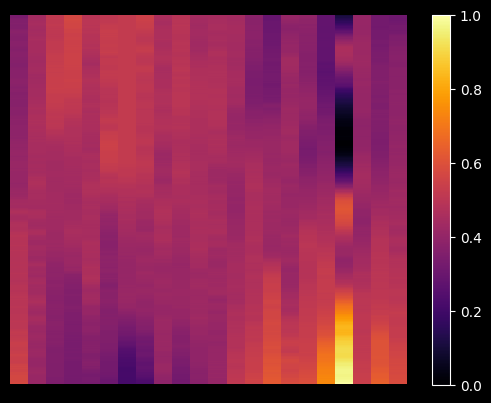

26263.250000002554 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.626, 0.0, 0.0, 0.0]


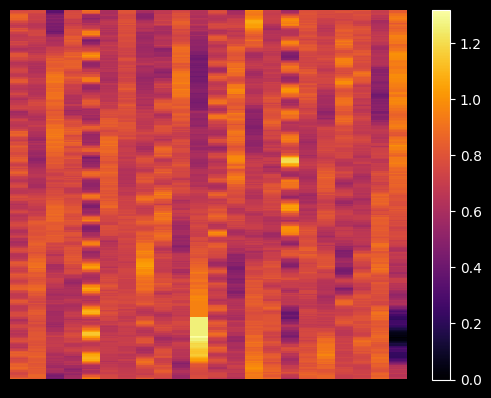

26261.000000002532 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9984, 0.9984]


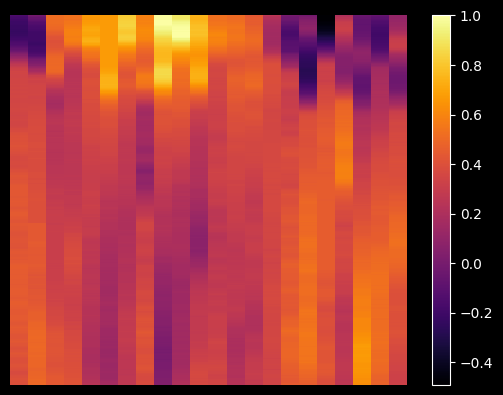

26238.350000002312 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8943, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
DbHealthCheck.cpp(146): Database service health check complete: Healthy


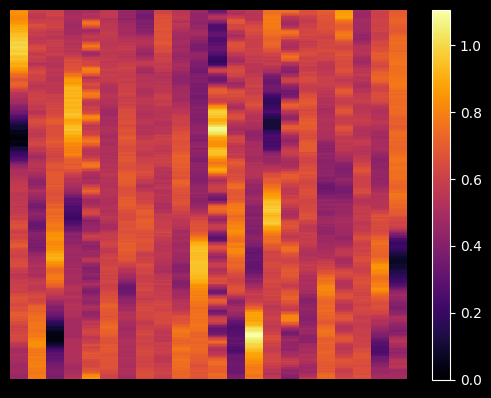

26198.600000001927 [0.0, 0.0, 0.1127, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9976, 0.9976]


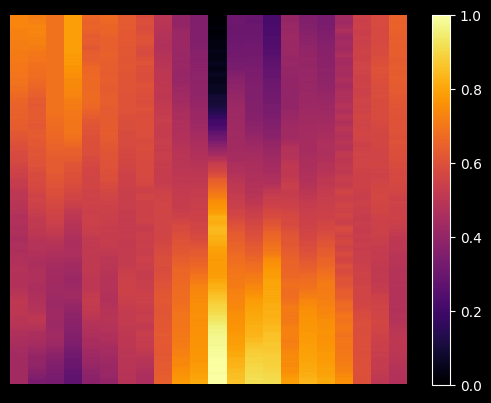

26090.000000000873 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.9853, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


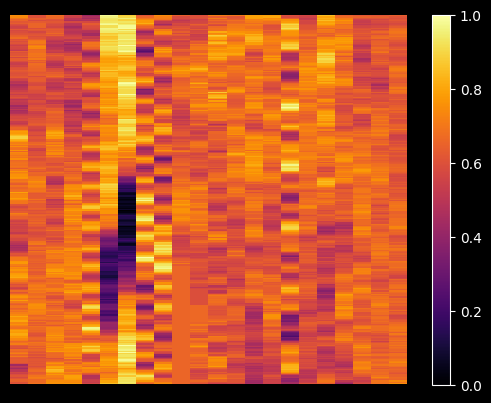

23579.000000005613 [0.0, 0.0, 0.0, 0.0, 0.0, 0.995, 0.9959, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


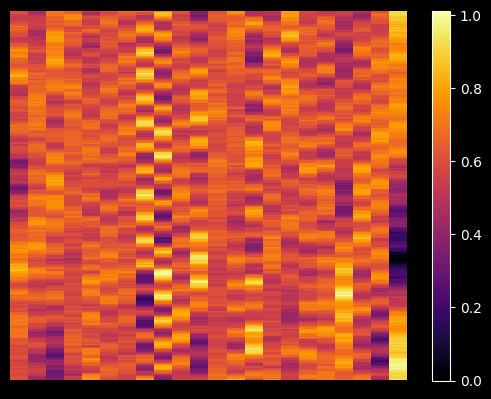

23535.500000005195 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.6861, 0.6861]


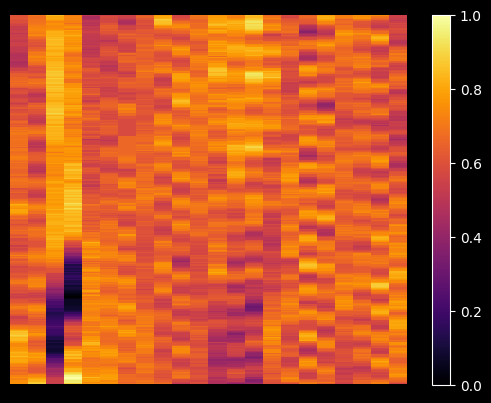

22650.250000006305 [0.0, 0.0, 0.0153, 0.1704, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.001, 0.001]


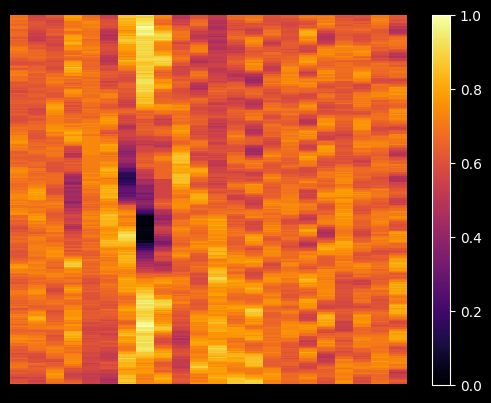

22575.550000005584 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.638, 0.3726, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


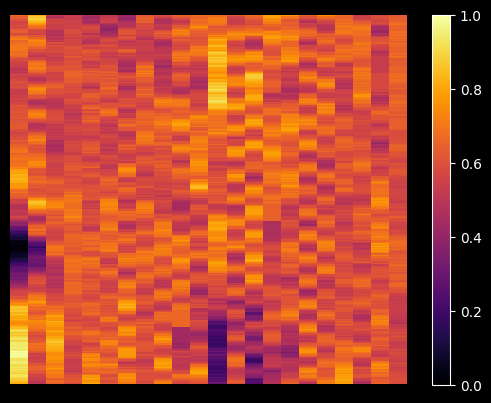

22456.300000004427 [0.3239, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


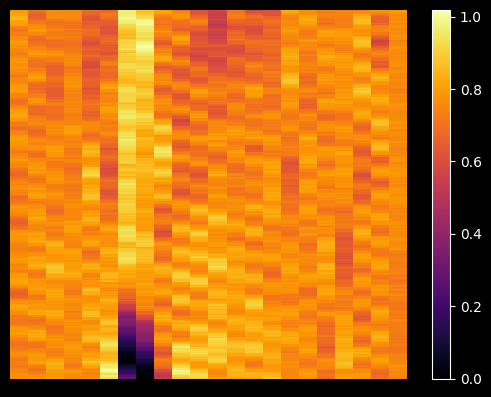

21303.300000002942 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9239, 0.1256, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


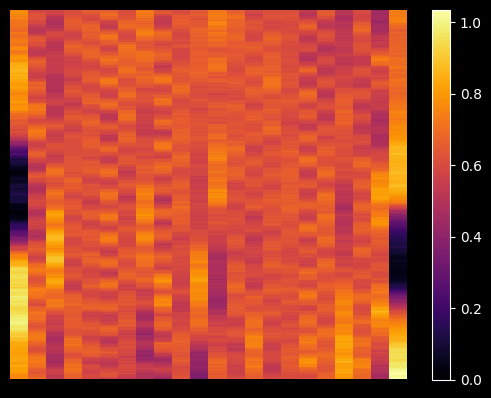

20482.700000004683 [0.0003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9961, 0.9961]


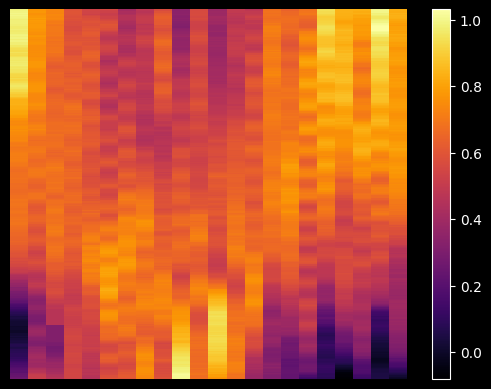

20291.75000000283 [0.3391, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


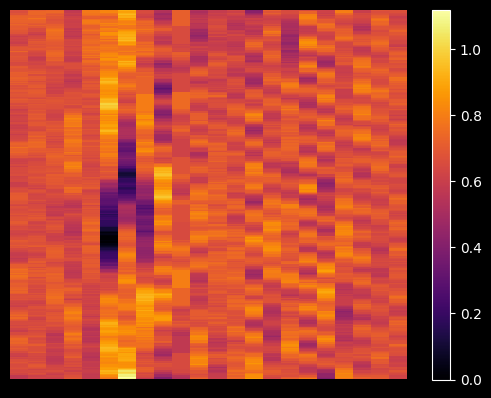

19078.45000000076 [0.0, 0.0, 0.0, 0.0, 0.0, 0.9779, 0.2584, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


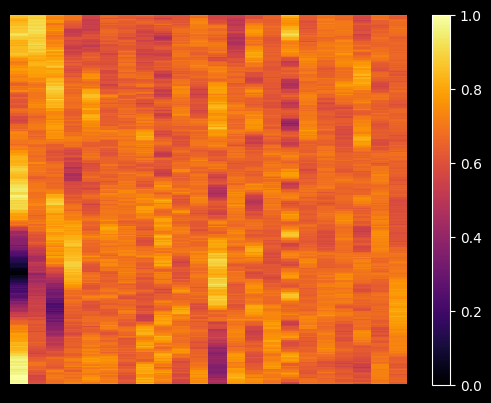

17542.10000000526 [0.9935, 0.6091, 0.4266, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


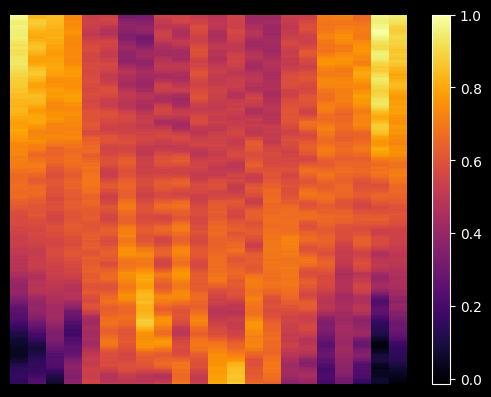

17112.800000001094 [0.2065, 0.0101, 0.3751, 0.7988, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0003, 0.0003]


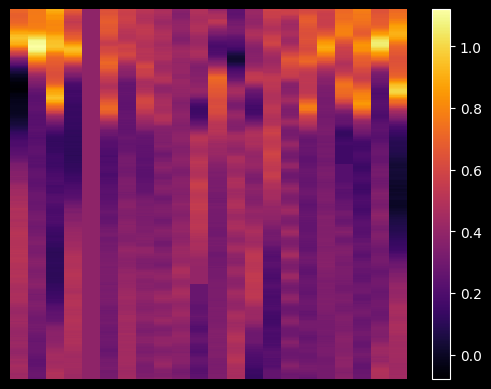

14844.499999997952 [0.0001, 0.0, 0.7394, 0.9219, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9742, 0.9742]


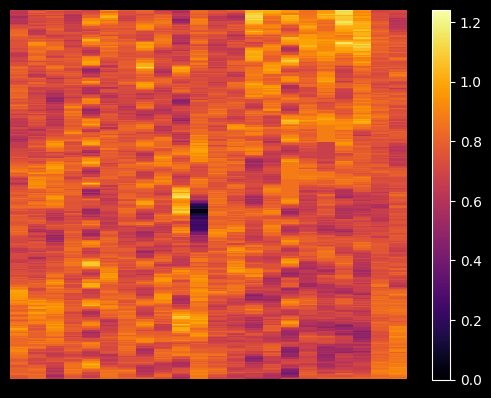

12655.79999999841 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9811, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


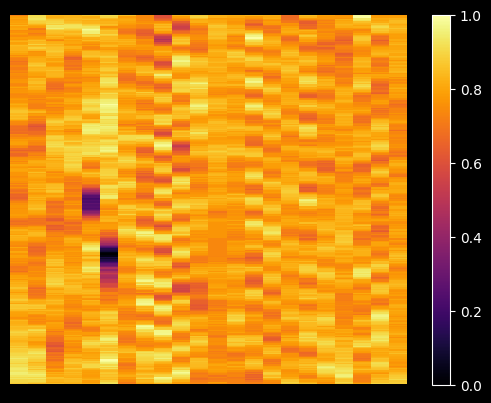

11760.949999998156 [0.0, 0.0, 0.0, 0.0, 0.2058, 0.925, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


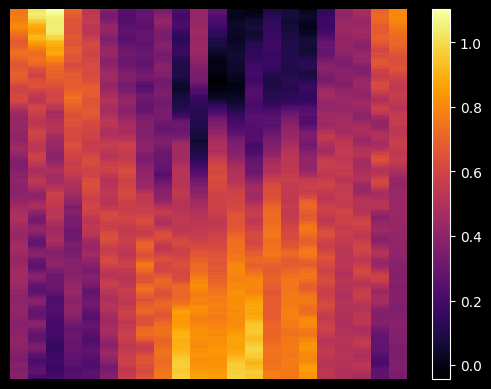

8548.09999999867 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.3379, 0.6359, 0.1519, 0.1588, 0.0006, 0.0031, 0.0079, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


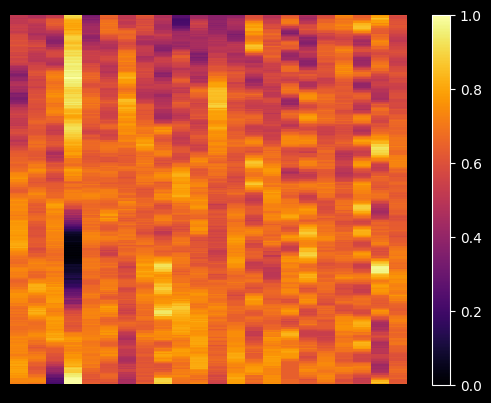

8004.799999999988 [0.0, 0.0, 0.0, 0.5976, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
DbHealthCheck.cpp(146): Database service health check complete: Healthy


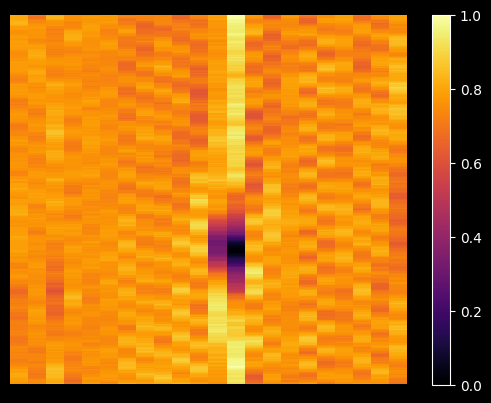

6421.649999998977 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9974, 0.9995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji


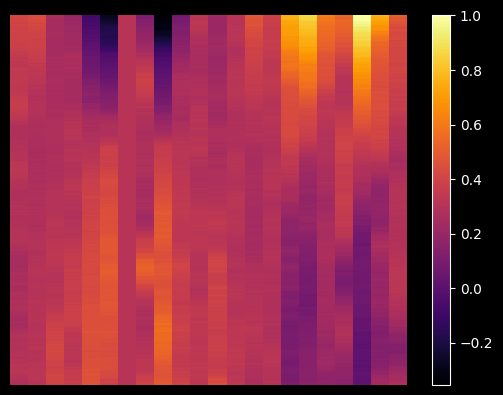

6417.749999998987 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002, 0.9611, 0.0003, 0.0005, 0.0005]


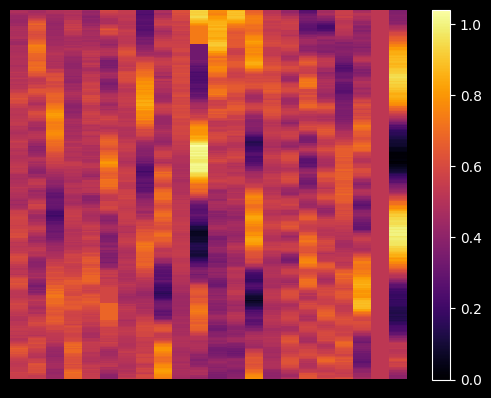

6385.949999999064 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2042, 0.2042]


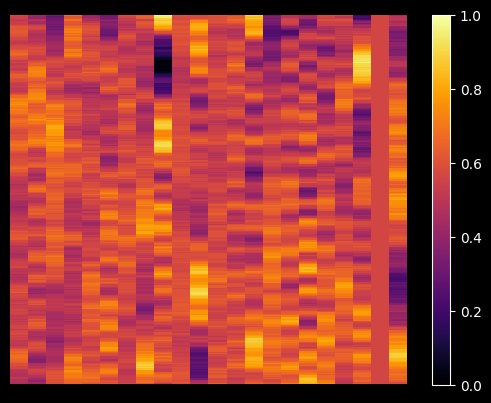

6385.649999999065 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5488, 0.5488]


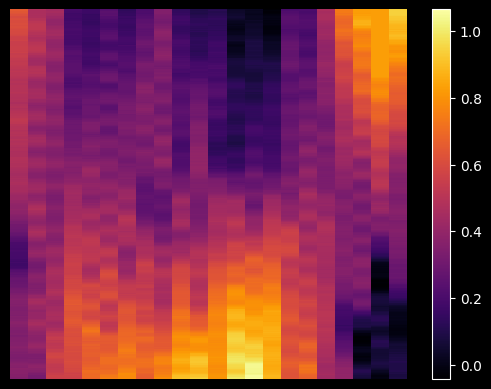

6383.54999999907 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0011, 0.114, 0.0, 0.0]


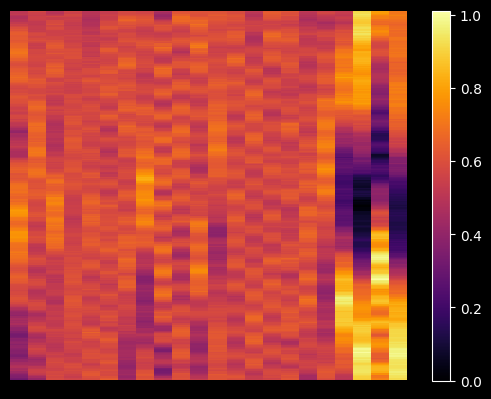

4937.5000000005675 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8941, 0.9514, 0.0142, 0.0142]


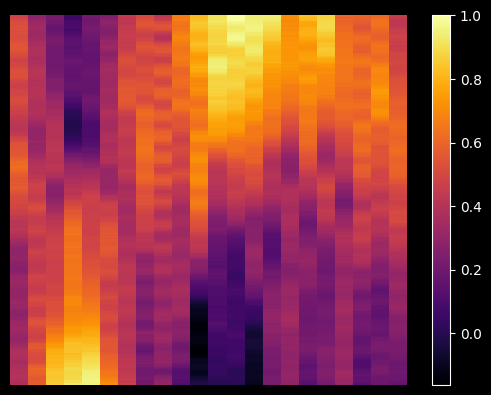

4196.20000000012 [0.0, 0.0, 0.0001, 0.1068, 0.0171, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


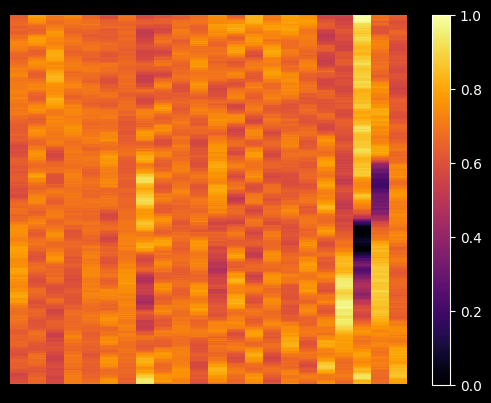

2766.800000000465 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9921, 0.0, 0.0]


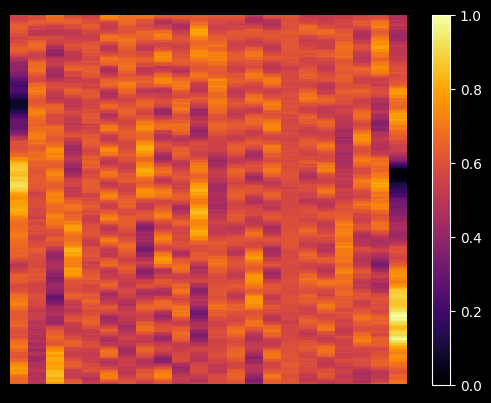

2288.600000000175 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9066, 0.9066]


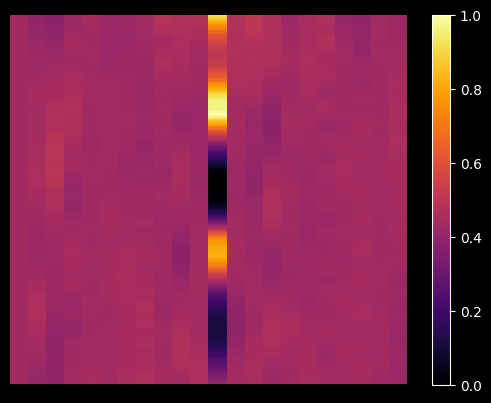

93.89999999999999 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2158, 0.9997, 0.0013, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


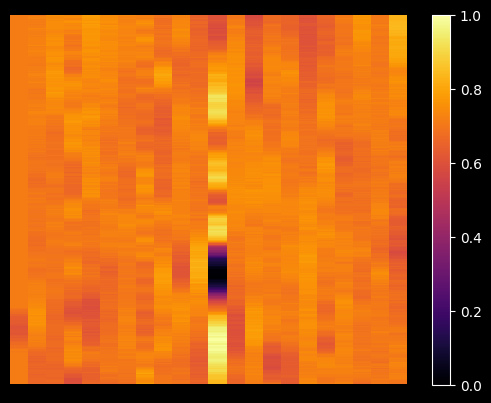

93.14999999999999 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9299, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


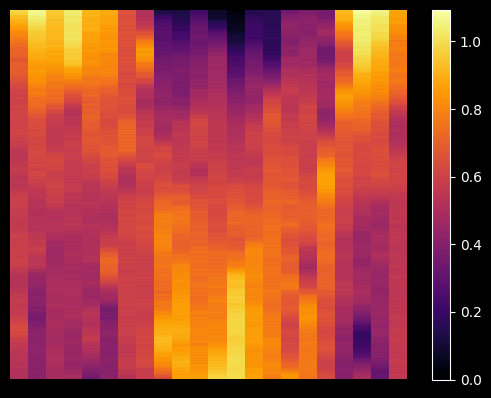

92.25 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1078, 0.0, 0.0]


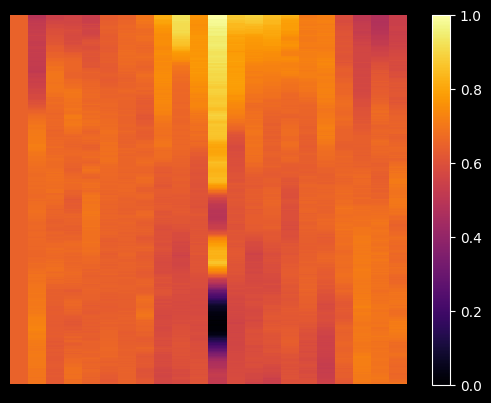

91.05000000000001 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.8929, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


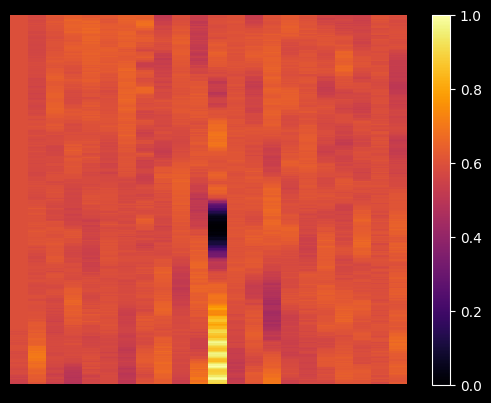

90.30000000000001 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.972, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


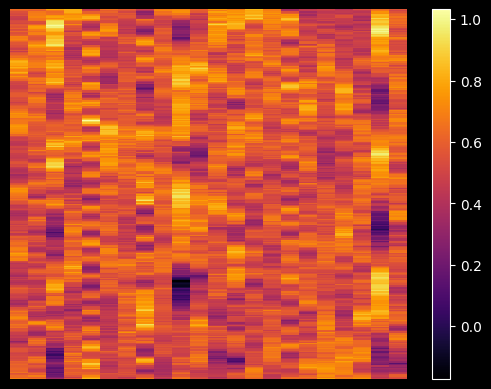

67.04999999999998 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1644, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


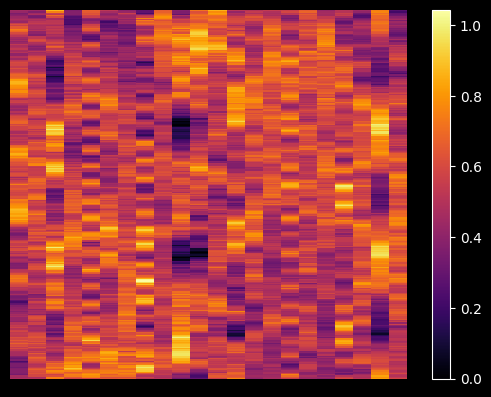

66.29999999999998 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9885, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


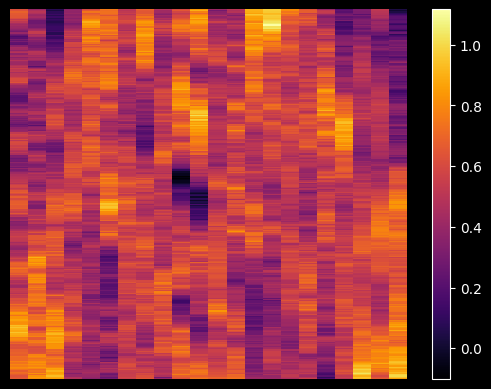

29.1 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9986, 0.9812, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


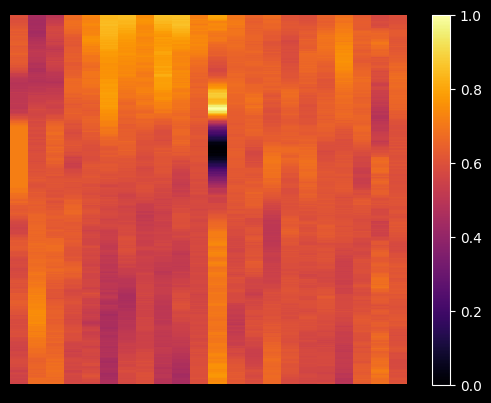

25.950000000000003 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.9522, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


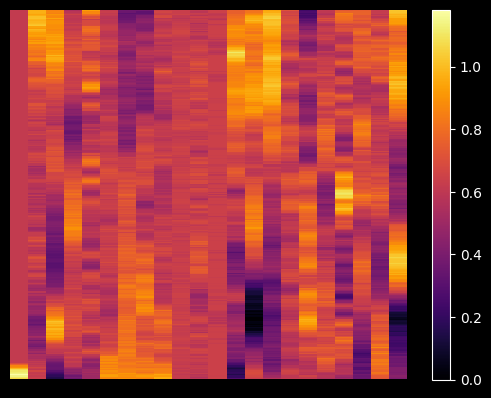

19.950000000000003 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0055, 0.9544, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0001]


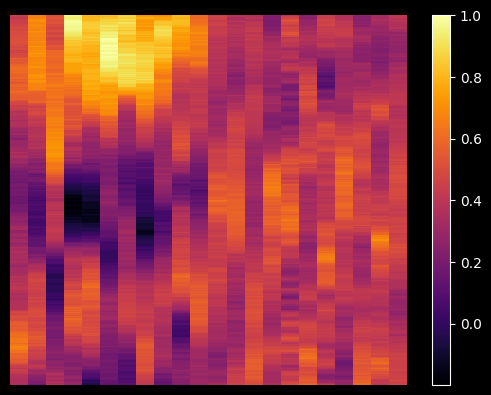

15.6 [0.0004, 0.0432, 0.001, 0.0127, 0.5923, 0.0008, 0.021, 0.0719, 0.0009, 0.3058, 0.0067, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


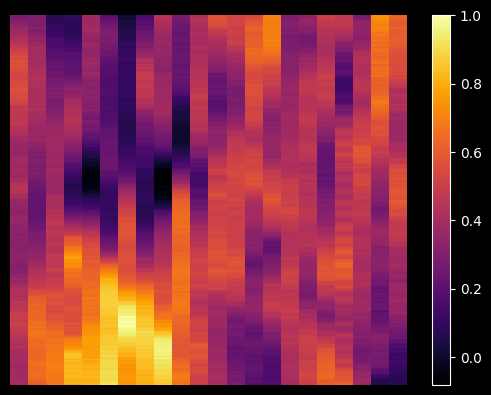

13.95 [0.0, 0.0003, 0.006, 0.0805, 0.07, 0.0297, 0.0643, 0.2653, 0.1027, 0.0051, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


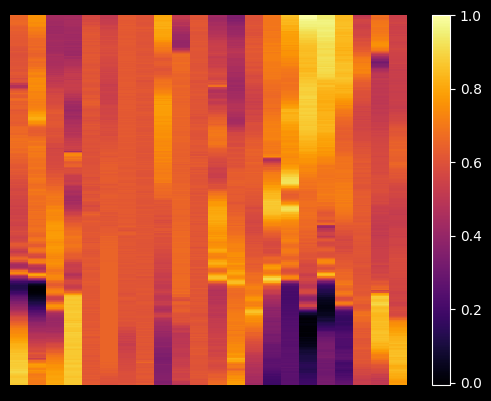

3.75 [0.9732, 0.8736, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


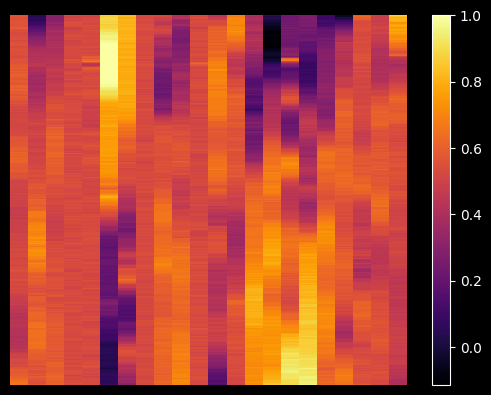

3.45 [0.0, 0.0, 0.0, 0.0, 0.0, 0.9935, 0.9969, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


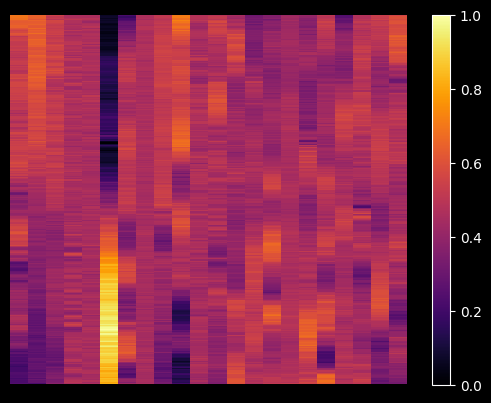

2.7 [0.0, 0.0, 0.0, 0.0, 0.0, 0.9816, 0.0181, 0.0, 0.0003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


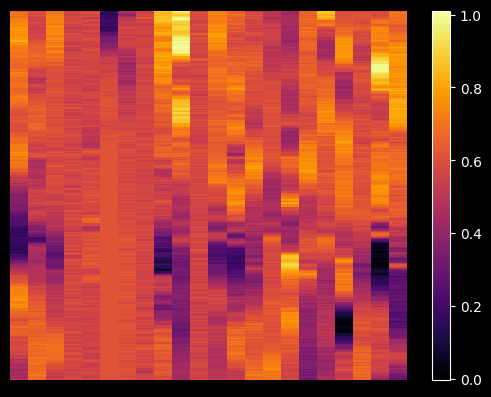

2.4 [0.0004, 0.0, 0.0001, 0.0, 0.0, 0.0008, 0.0, 0.0, 0.1632, 0.0001, 0.0, 0.2713, 0.0019, 0.0, 0.0008, 0.0, 0.0, 0.0006, 0.0, 0.0, 0.0, 0.0]


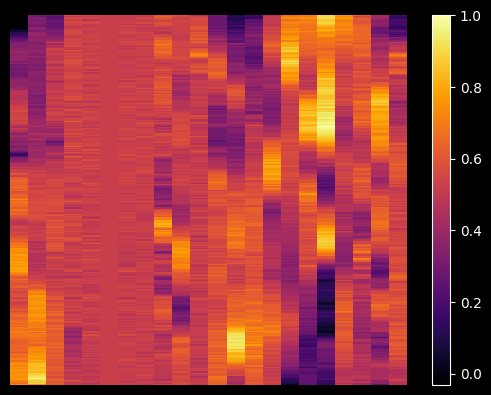

2.1 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.2249, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


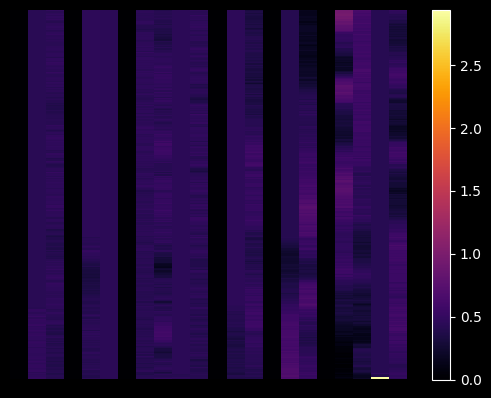

1.65 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1034, 0.0005, 0.0001, 0.002, 0.0, 0.0, 0.0]


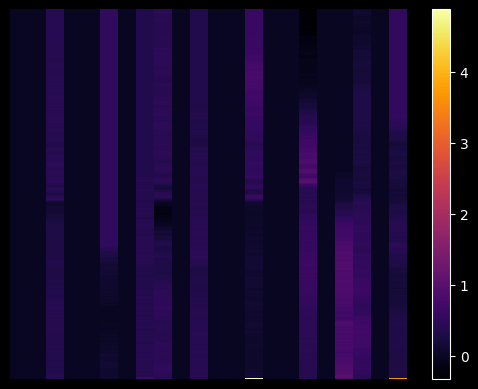

1.05 [0.0012, 0.0, 0.0007, 0.0, 0.0, 0.0098, 0.0, 0.0005, 0.8142, 0.0, 0.0, 0.0011, 0.0, 0.0, 0.0005, 0.0001, 0.0003, 0.0055, 0.0002, 0.0005, 0.0, 0.0]


In [17]:
for i, row in filtered_df_deduped.iterrows():
    vd = (row['start']+ row['end'])/2
    img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")

    print(vd, row['prob'])

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


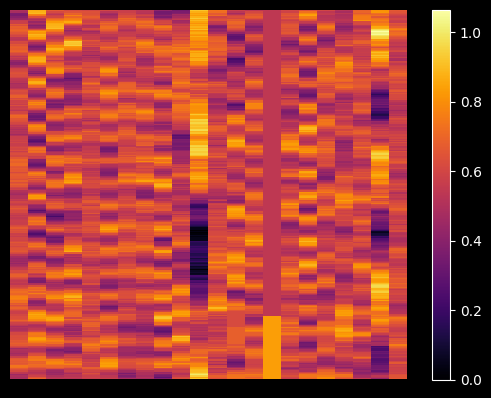

In [26]:
img_std = gen_image(4100, session, dist_corr, length=0.3, show_im=True, normalize="std")